# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options.sampler_options import SamplerOptions

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as QCrankV2, analyze_qcrank_residuals

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [3]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x0000027EC173E210>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [4]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [5]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [6]:
def plot_residuals(actual, theory, title, x_label, y_label, legend):
    min_val = min(min(actual), min(theory))
    max_val = max(max(actual), max(theory))

    plt.scatter(theory, actual, label=legend)
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")
    # plot line of best fit
    plt.plot(theory, np.poly1d(coefficients)(theory), color='red', label='Line of Best Fit')    

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.grid(True)

    plt.show()

In [7]:
def ehands_addition(qc, q_a, q_b, weight, negation=False, verbose=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    if verbose:
        print("Addition Circuit:")
        display(qc_add.draw('mpl'))
    
    return qc.compose(qc_add, qubits=[q_a, q_b])


## Vertex Classification Setup with QCrank

In [8]:
def configure_qcrank_options(n_shots):
    options = SamplerOptions()
    options.default_shots=n_shots
    return options

In [9]:
def run_sim_job_qcrank(encoding_args, n_shots = 2**12, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param encoding_args: dictionary including information about the QC of encoded data
    :param n_shots: number of shots to run
    :param verbose: print out extra details and draw circuit

    :return: Counts of the measurement outcomes
    """
    options = configure_qcrank_options(n_shots)
    sampler = Sampler(mode=sim, options=options)

    job = sampler.run(tuple(encoding_args['qcEL']))
    jobRes = job.result()

    #countsL = [jobRes[0].data.meas.get_counts()]
    countsL = [jobRes[0].data.c.get_counts()]

    if verbose:
        qc = encoding_args['qc']
        cxDepth=qc.depth(filter_function=lambda x: x.operation.name == 'cx')
        print(f'.... PARAMETRIZED CIRCUIT .............., cx-depth={cxDepth}')
        print('Gates count:', qc.count_ops())
        display(qc.draw('mpl'))


    return countsL

In [10]:
def initialize_n_data(n_cubes, data_range, make_iso_array=False, isovalue=0.5):
    n_data = 2**3 # data per array
    nq_addr = math.ceil(math.log2(n_data))
    nq_data = n_cubes

    if make_iso_array:
        n_arr -= 1
        
    data_inp = np.random.uniform(data_range[0], data_range[1], size=(n_data, nq_data, 1))
    print(f"data shape: {data_inp.shape}")

    if make_iso_array:
        data_inp.append(np.full((n_data, 1), isovalue))

    return {
        'n_data': n_data,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'num_q': nq_addr + nq_data,
        'addr_qL': list(range(nq_addr)),
        'data_qL': list(range(nq_addr, nq_addr + nq_data)),
        'data_inp': data_inp
    }

In [11]:
def encode_with_qcrank_2(data_args, useCZ=False, measure=True, barrier=True):
    nq_addr = data_args['nq_addr']
    nq_data = data_args['nq_data']

    qcrankObj = QCrankV2(nq_addr, nq_data, useCZ=useCZ, measure=measure, barrier=barrier)

    qc = qcrankObj.circuit
    
    qcrankObj.bind_data(data_args['data_inp'])

    qcEL = qcrankObj.instantiate_circuits()

    print(f"Created {len(qcEL)} circuits")
    return {
        'qc': qc,
        'qcEL': qcEL,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'qcrankObj': qcrankObj
    }

In [12]:
def analyze_all_qcrank_residuals(data_args, data_rec, all_data_list, all_rec_list, verbose=False):
    # Iterate over all input arrays
    for i in range(data_args['nq_data']):
        # Save data and recovered to lists
        data_slice = data_args['data_inp'][:, i:i+1, :]
        rec_slice = data_rec[:, i:i+1, :]

        all_data_list[i].append(data_slice)
        all_rec_list[i].append(rec_slice)

        # QCrank analysis
        print(f"Analyzing residuals for array {i}")
        analyze_qcrank_residuals(data_slice, rec_slice)
        
        if verbose:
            print(f'\nCube original data:\n', data_slice)
            print(f'Reconstructed data:\n', rec_slice)
            print(f'Difference:\n', (data_slice - rec_slice))
            if i > 2: 
                break

In [13]:
def add_iso_qubit_for_ehands(qc, data_q, placement_q, isovalue, weight, negation=True, verbose=False):
    qc_iso = QuantumCircuit(1, 1)
    qc_iso.ry(np.arccos(isovalue), 0)

    qc.compose(qc_iso, placement_q, inplace=True)

    qc.barrier()
    qc = ehands_addition(qc, data_q, placement_q, weight=weight, verbose=verbose)
    qc.barrier()

    return qc


## Method 2
### Encode Data array using QCrank, encode Isovalue using single Ry gate

Chose method 2 because it produces the same result as method 1 with far fewer gates

In [14]:
def test_qcrank_ehands_single_iso_n_data(n_cubes):
    isovalue = 0.5
    weight = 0.5
    verbose = True

    all_data_list = [[] for _ in range(n_cubes)]
    all_rec_list = [[] for _ in range(n_cubes)]
    
    for _ in range(20):
        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + n_cubes, data_args['num_q'] + n_cubes)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        print(f"data_qL: {data_args['data_qL']}")

        # add iso value qubit 
        for i in range(n_cubes):
            q_a = data_args['data_qL'][i]
            q_b = data_args['num_q'] + i 
            print(f"q_a: {q_a}, q_b: {q_b}, for i: {i}")
            qc_main = add_iso_qubit_for_ehands(qc_main, q_a, q_b, isovalue, weight, verbose=verbose)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)
        
        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, data_rec, all_data_list, all_rec_list, verbose=verbose)
        
        # verbose for first iteration to draw circuit
        verbose = False
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

data shape: (8, 2, 1)
Created 1 circuits
data_qL: [3, 4]
q_a: 3, q_b: 5, for i: 0
Addition Circuit:


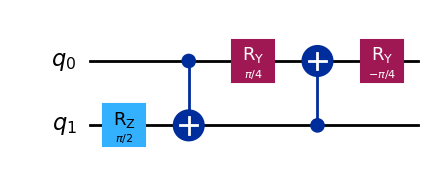

q_a: 4, q_b: 6, for i: 1
Addition Circuit:


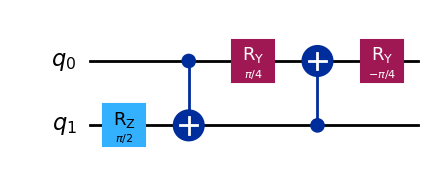

.... PARAMETRIZED CIRCUIT .............., cx-depth=12
Gates count: OrderedDict({'ry': 22, 'cx': 20, 'barrier': 6, 'measure': 5, 'h': 3, 'rz': 2})


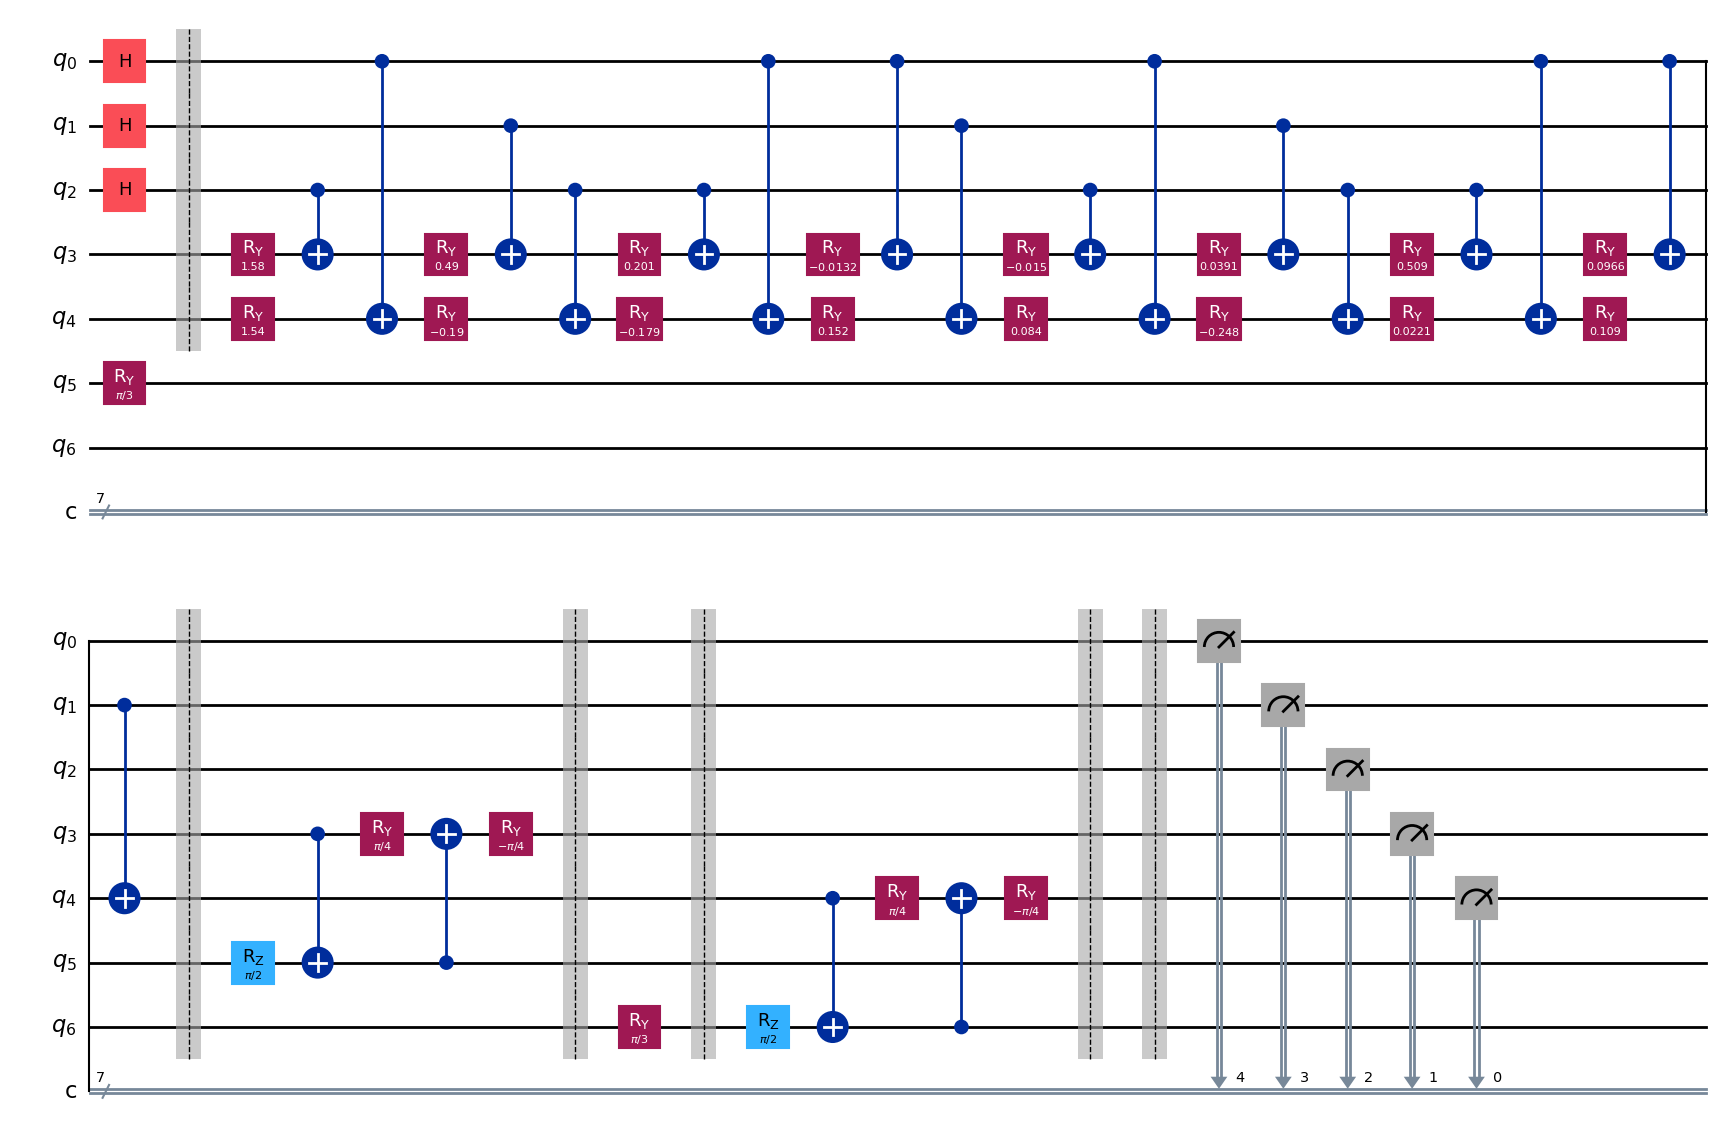

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.240  std= 0.297  corr=1.00   tilt angle=2.1/deg
Overall 
residuals: mean=-0.240  std=0.297  corr=0.999


Cube original data:
 [[[-0.96815191]]

 [[ 0.9173316 ]]

 [[-0.77934947]]

 [[ 0.58435833]]

 [[-0.05817602]]

 [[ 0.22588324]]

 [[ 0.26631818]]

 [[-0.09255407]]]
Reconstructed data:
 [[[-0.22709552]]

 [[ 0.71587072]]

 [[-0.15570765]]

 [[ 0.53433424]]

 [[ 0.19793966]]

 [[ 0.35055351]]

 [[ 0.39376218]]

 [[ 0.20203983]]]
Difference:
 [[[-0.74105639]]

 [[ 0.20146088]]

 [[-0.62364182]]

 [[ 0.0500241 ]]

 [[-0.25611568]]

 [[-0.12467026]]

 [[-0.127444  ]]

 [[-0.29459389]]]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean=-0.238  std= 0.192  corr=1.00   tilt angle=3.8/deg
Overall 
residuals: mean=-0.238  std=0.192  corr=0.998


Cube original data:
 [[[ 0.2794526 ]]

 [[-0.0

In [24]:
n_cubes = 2
all_rec_list, all_data_list = test_qcrank_ehands_single_iso_n_data(n_cubes)

-----------------------------Analysis of Original Cube 1 vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.968152      | -0.227096      | -0.741056      |
| 0.917332       | 0.715871       | 0.201461       |
| -0.779349      | -0.155708      | -0.623642      |
| 0.584358       | 0.534334       | 0.050024       |
| -0.058176      | 0.197940       | -0.256116      |
| 0.225883       | 0.350554       | -0.124670      |
| 0.266318       | 0.393762       | -0.127444      |
| -0.092554      | 0.202040       | -0.294594      |
| 0.886286       | 0.679522       | 0.206764       |
| -0.767522      | -0.116435      | -0.651087      |
| -0.214753      | 0.130160       | -0.344914      |
| -0.893833      | -0.174988      | -0.718845      |
| -0.487420      | 0.007590       | -0.495010      |
| 0.881628       | 0.691166       | 0.190463

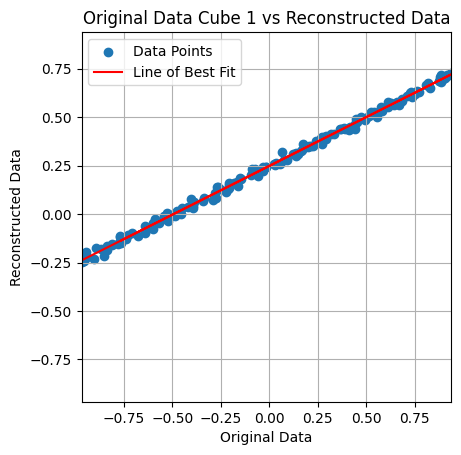

-----------------------------Analysis of Original Cube 2 vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.279453       | 0.403996       | -0.124544      |
| -0.098063      | 0.209841       | -0.307904      |
| 0.216014       | 0.346370       | -0.130356      |
| 0.472456       | 0.482156       | -0.009700      |
| -0.787437      | -0.130243      | -0.657194      |
| 0.406312       | 0.472571       | -0.066259      |
| -0.068699      | 0.223197       | -0.291896      |
| -0.071600      | 0.246236       | -0.317836      |
| -0.662318      | -0.071411      | -0.590907      |
| -0.130337      | 0.182559       | -0.312896      |
| 0.380858       | 0.432734       | -0.051876      |
| 0.625831       | 0.565002       | 0.060829       |
| -0.988169      | -0.262334      | -0.725835      |
| -0.833876      | -0.186340      | -0.64753

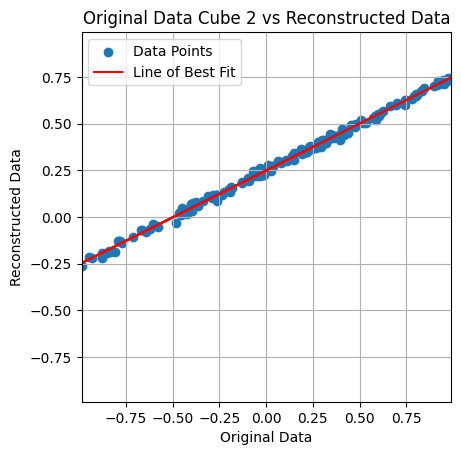

In [25]:
for i in range(n_cubes):
    print(f"-----------------------------Analysis of Original Cube {i + 1} vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Data  | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[i]).flatten(),
                    np.concatenate(all_rec_list[i]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[i]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = f'Original Data Cube {i + 1} vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[i]).flatten(),
                    np.concatenate(all_data_list[i]).flatten(), 
                    title, x_label, y_label, legend)